In [33]:
import ast
import mglearn #library provided by amueller
import numpy as np
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction import FeatureHasher
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
pd.options.display.float_format = '{:,.2g}'.format

In [34]:
df = pd.read_csv('games_steam.csv')
df.shape

C:\Users\Drei Abmab\AppData\Local\Temp\ipykernel_30252\957210396.py:1: DtypeWarning: Columns (0: windows, 1: mac, 2: linux, 3: metacritic_score, 4: achievements, 5: recommendations, 6: user_score, 7: positive, 8: negative, 9: average_playtime_forever, 10: average_playtime_2weeks, 11: median_playtime_forever, 12: median_playtime_2weeks, 13: discount, 14: peak_ccu, 15: pct_pos_total, 16: num_reviews_total, 17: pct_pos_recent, 18: num_reviews_recent) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('games_steam.csv')


(94954, 44)

In [35]:
df.head()

,appid,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,...,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent
0,7.3e+02,Counter-Strike 2,8/21/2012,0,0,1,"For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...",NaN,...,879,5174,350,0,1212356,"{'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...",86,8632939,82,96473
1,5.8e+05,PUBG: BATTLEGROUNDS,12/21/2017,0,0,0,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...","LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",Play PUBG: BATTLEGROUNDS for free. Land on str...,NaN,...,0,0,0,0,616738,"{'Survival': 14838, 'Shooter': 12727, 'Battle ...",59,2513842,68,16720
2,5.7e+02,Dota 2,7/9/2013,0,0,2,"The most-played game on Steam. Every day, mill...","The most-played game on Steam. Every day, mill...","Every day, millions of players worldwide enter...",“A modern multiplayer masterpiece.” 9.5/10 – D...,...,1536,898,892,0,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81,2452595,80,29366
3,2.7e+05,Grand Theft Auto V Legacy,4/13/2015,17,0,0,"When a young street hustler, a retired bank ro...","When a young street hustler, a retired bank ro...",Grand Theft Auto V for PC offers players the o...,NaN,...,771,7101,74,0,117698,"{'Open World': 32644, 'Action': 23539, 'Multip...",87,1803832,92,17517
4,4.9e+05,Tom Clancy's Rainbow Six® Siege,12/1/2015,17,20,9,Edition Comparison Ultimate Edition The Tom Cl...,“One of the best first-person shooters ever ma...,"Tom Clancy's Rainbow Six® Siege is an elite, t...",NaN,...,0,0,0,0,0,"{'FPS': 8082, 'Multiplayer': 6139, 'Tactical':...",84,1168404,76,13017


In [36]:
print(df.columns)

Index(['appid', 'name', 'release_date', 'required_age', 'price', 'dlc_count',
       'detailed_description', 'about_the_game', 'short_description',
       'reviews', 'header_image', 'website', 'support_url', 'support_email',
       'windows', 'mac', 'linux', 'metacritic_score', 'achievements',
       'recommendations', 'supported_languages', 'full_audio_languages',
       'packages', 'developers', 'publishers', 'categories', 'genres',
       'screenshots', 'movies', 'user_score', 'positive', 'negative',
       'estimated_owners', 'average_playtime_forever',
       'average_playtime_2weeks', 'median_playtime_forever',
       'median_playtime_2weeks', 'discount', 'peak_ccu', 'tags',
       'pct_pos_total', 'num_reviews_total', 'pct_pos_recent',
       'num_reviews_recent'],
      dtype='str')


In [37]:
df.dtypes


appid                       float64
name                            str
release_date                    str
required_age                float64
price                       float64
dlc_count                   float64
detailed_description            str
about_the_game                  str
short_description               str
reviews                         str
header_image                    str
website                         str
support_url                     str
support_email                   str
windows                      object
mac                          object
linux                        object
metacritic_score             object
achievements                 object
recommendations              object
supported_languages             str
full_audio_languages            str
packages                        str
developers                      str
publishers                      str
categories                      str
genres                          str
screenshots                 

## III. Checking Missing Values

Before training regression models, the dataset must be checked for missing values. Missing values may affect the training process and lead to unreliable results.

In [38]:
df.isna().sum()

appid                          10
name                           13
release_date                   11
required_age                   11
price                          11
dlc_count                      11
detailed_description         5436
about_the_game               5460
short_description            5359
reviews                     84523
header_image                   10
website                     53762
support_url                 50771
support_email               16105
windows                         7
mac                             6
linux                           6
metacritic_score                6
achievements                    6
recommendations                 5
supported_languages          5416
full_audio_languages        55093
packages                    19079
developers                   5455
publishers                   5784
categories                   5911
genres                       5445
screenshots                  3457
movies                       7669
user_score    

## IV. Data Cleaning

The dataset is cleaned to make it suitable for regression modeling.

The following cleaning steps are performed:
- removing unnecessary columns
- trimming extra spaces from column names and values
- removing dirty text patterns and symbols
- dropping rows with remaining missing values after cleaning



In [39]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df.isna().sum()

appid                          10
name                           13
release_date                   11
required_age                   11
price                          11
dlc_count                      11
detailed_description         5436
about_the_game               5460
short_description            5359
reviews                     84523
header_image                   10
website                     53762
support_url                 50771
support_email               16105
windows                         7
mac                             6
linux                           6
metacritic_score                6
achievements                    6
recommendations                 5
supported_languages          5416
full_audio_languages        55093
packages                    19079
developers                   5455
publishers                   5784
categories                   5911
genres                       5445
screenshots                  3457
movies                       7669
user_score    

In [40]:
print(df.shape)

(94954, 44)


In [41]:
df_clean = df.copy()

# Remove extra spaces from column names
df_clean.columns = df_clean.columns.str.strip()

# Remove columns with too many missing values (> 20,000 NaNs)
# This helps improve data quality by dropping features that are
# too sparse to be useful for analysis or machine learning.
# Rows are NOT affected.
threshold = 20000
df_clean = df_clean.loc[:, df.isna().sum() <= threshold]

# Drop Colunms because it is not relevant
cols_to_drop = [
    "screenshots",
    "about_the_game",
    "short_description",
    "website",
    "support_url",
    "support_email",
    "movies"
    "header_image",
    "release_date",
    "detailed_description",
    "header_image",
    "packages"
]

df_clean = df_clean.drop(columns=cols_to_drop, errors="ignore")


def clean_numeric_series(series):
    return pd.to_numeric(
        series.astype(str)
        .str.strip()
        .str.replace(r"^id_", "", regex=True)
        .str.replace(r"_x$", "", regex=True)
        .str.replace("$", "", regex=False)
        .str.replace("%", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.replace("abc", "", regex=False)
        .replace("nan", np.nan),
        errors="coerce"
    )

print("Shape after cleaning and conversion:", df_clean.shape)
print("\nMissing values after conversion:\n")
print(df_clean.isnull().sum().sort_values(ascending=False).head(20))



Shape after cleaning and conversion: (94954, 31)

Missing values after conversion:

movies                 7669
categories             5911
publishers             5784
developers             5455
genres                 5445
supported_languages    5416
name                     13
dlc_count                11
price                    11
required_age             11
appid                    10
windows                   7
achievements              6
metacritic_score          6
mac                       6
linux                     6
recommendations           5
user_score                4
positive                  4
negative                  4
dtype: int64


In [42]:
df_clean = df_clean.dropna()

print("Final cleaned shape:", df_clean.shape)
print("\nRemaining missing values:\n")
print(df_clean.isnull().sum().sort_values(ascending=False).head(20))


Final cleaned shape: (85939, 31)

Remaining missing values:

appid                  0
name                   0
required_age           0
price                  0
dlc_count              0
windows                0
mac                    0
linux                  0
metacritic_score       0
achievements           0
recommendations        0
supported_languages    0
developers             0
publishers             0
categories             0
genres                 0
movies                 0
user_score             0
positive               0
negative               0
dtype: int64


### Converting values

In [43]:
bool_cols = ["windows", "mac", "linux"]

# convert true and false values to 1's and 0's
df_clean[bool_cols] = df_clean[bool_cols].apply(
    lambda col: col.astype(str).str.strip().str.upper().map({
        "TRUE": 1,
        "FALSE": 0
    })
)

In [44]:
list_cols = ["supported_languages", "developers", "publishers", "categories", "genres"]

for col in list_cols:
    df_clean[col] = df_clean[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

In [45]:
mlb = MultiLabelBinarizer()

lang_encoded = mlb.fit_transform(df_clean["supported_languages"])

lang_df = pd.DataFrame(lang_encoded, columns=[f"lang_{c}" for c in mlb.classes_])

df_clean = df_clean.join(lang_df)

In [46]:
top_devs = df_clean["developers"].explode().value_counts().head(200).index

df_clean["developers_filtered"] = df_clean["developers"].apply(
    lambda x: [i for i in x if i in top_devs]
)

mlb = MultiLabelBinarizer()
dev_encoded = mlb.fit_transform(df_clean["developers_filtered"])

dev_df = pd.DataFrame(dev_encoded, columns=[f"dev_{c}" for c in mlb.classes_], index=df_clean.index)

df_clean = pd.concat([df_clean, dev_df], axis=1)

In [47]:
top_pub = df_clean["publishers"].explode().value_counts().head(200).index

df_clean["publishers_filtered"] = df_clean["publishers"].apply(
    lambda x: [i for i in x if i in top_pub]
)

mlb_pub = MultiLabelBinarizer()

pub_encoded = mlb_pub.fit_transform(df_clean["publishers_filtered"])

pub_df = pd.DataFrame(
    pub_encoded,
    columns=[f"pub_{c}" for c in mlb_pub.classes_],
    index=df_clean.index
)

df_clean = pd.concat([df_clean, pub_df], axis=1)

In [48]:
mlb_cat = MultiLabelBinarizer()

cat_encoded = mlb_cat.fit_transform(df_clean["categories"])

cat_df = pd.DataFrame(
    cat_encoded,
    columns=[f"cat_{c}" for c in mlb_cat.classes_],
    index=df_clean.index
)

df_clean = pd.concat([df_clean, cat_df], axis=1)

In [49]:
mlb_gen = MultiLabelBinarizer()

gen_encoded = mlb_gen.fit_transform(df_clean["genres"])

gen_df = pd.DataFrame(
    gen_encoded,
    columns=[f"genre_{c}" for c in mlb_gen.classes_],
    index=df_clean.index
)

df_clean = pd.concat([df_clean, gen_df], axis=1)

In [50]:
df_clean = df_clean.drop(columns=["supported_languages", "developers", "publishers", "categories", "genres"])

In [51]:
df_clean

,appid,name,required_age,price,dlc_count,windows,mac,linux,metacritic_score,achievements,...,genre_Short,genre_Simulation,genre_Software Training,genre_Sports,genre_Strategy,genre_Tutorial,genre_Utilities,genre_Video Production,genre_Violent,genre_Web Publishing
0,7.3e+02,Counter-Strike 2,0,0,1,1,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
2,5.7e+02,Dota 2,0,0,2,1,1,1,90,0,...,0,0,0,0,1,0,0,0,0,0
3,2.7e+05,Grand Theft Auto V Legacy,17,0,0,1,0,0,96,77,...,0,0,0,0,0,0,0,0,0,0
4,4.9e+05,Tom Clancy's Rainbow Six® Siege,17,20,9,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,4.4e+02,Team Fortress 2,0,0,1,1,0,1,92,520,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94949,2.1e+06,Outrun Them,0,4,0,1,0,0,0,6,...,0,0,0,0,0,0,0,0,0,0
94950,1.2e+06,Lands of Pharaoh: Episode 1,0,10,0,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
94951,1.2e+06,Player One,0,2,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
94952,3.4e+06,DragonRoad,0,30,0,1,0,0,0,34,...,0,1,0,0,1,0,0,0,0,0


In [52]:
df_clean.dtypes

appid                     float64
name                          str
required_age              float64
price                     float64
dlc_count                 float64
                           ...   
genre_Tutorial              int64
genre_Utilities             int64
genre_Video Production      int64
genre_Violent               int64
genre_Web Publishing        int64
Length: 604, dtype: object

## V. Correlation 
To visualize the strength and direction of relationships among the variables, we use the correlation heatmap.


c:\Users\Drei Abmab\OneDrive\Documents\Coding Projects\41_50\42_Linear_Regression\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 20919 (\N{CJK UNIFIED IDEOGRAPH-51B7}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\Drei Abmab\OneDrive\Documents\Coding Projects\41_50\42_Linear_Regression\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 31505 (\N{CJK UNIFIED IDEOGRAPH-7B11}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\Drei Abmab\OneDrive\Documents\Coding Projects\41_50\42_Linear_Regression\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 40657 (\N{CJK UNIFIED IDEOGRAPH-9ED1}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\Drei Abmab\OneDrive\Documents\Coding Projects\41_50\42_Linear_Regression\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 22934 (\N{CJK UNIFIED IDEOGRAPH-5996}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\Drei Abmab\OneDrive\Documents\Codin

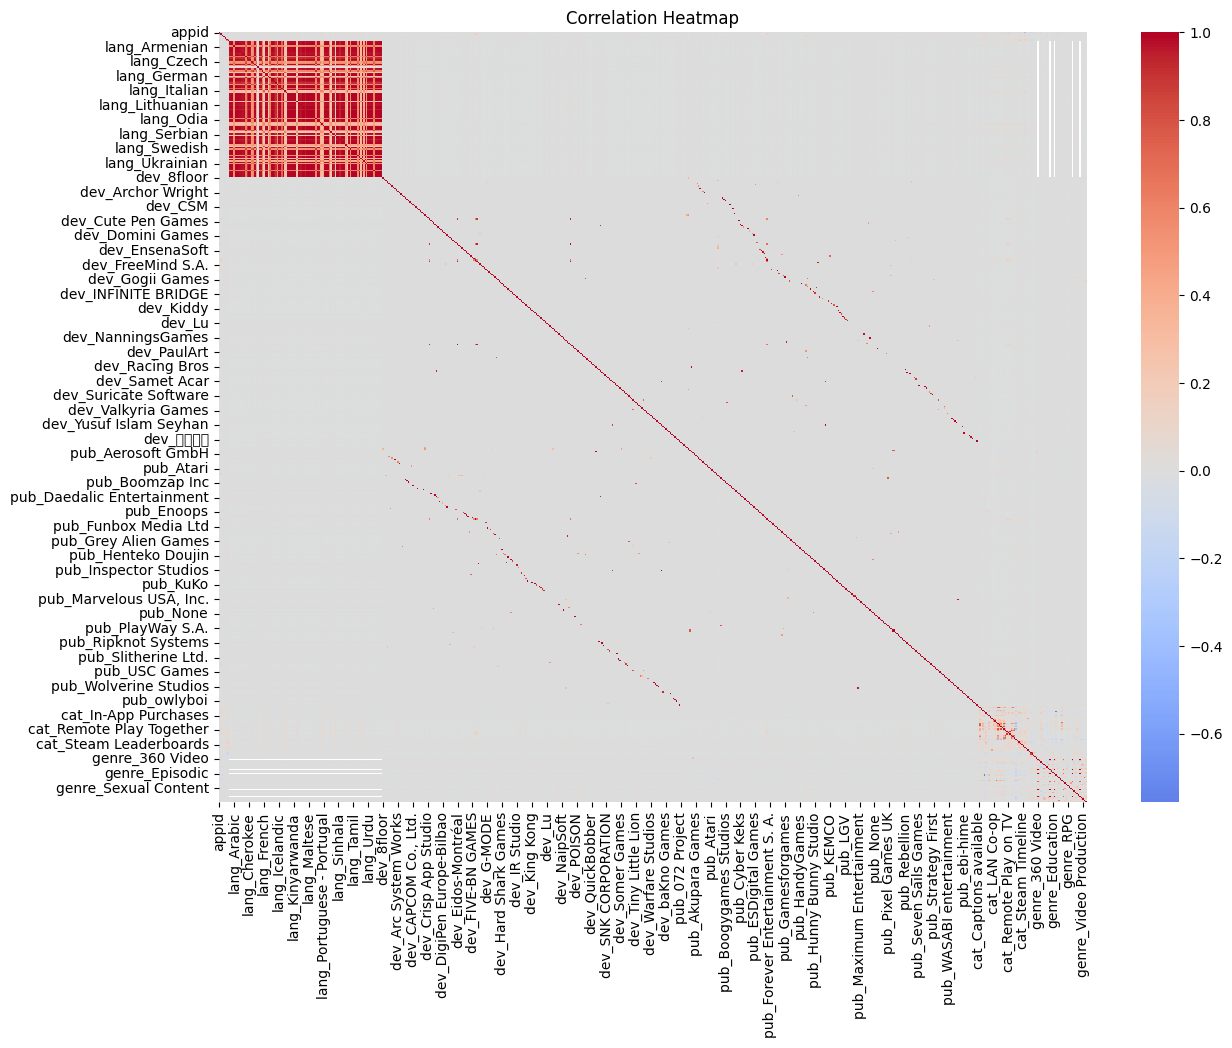

In [53]:
plt.figure(figsize=(14, 10))
sns.heatmap(df_clean.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()


The correlation analysis shows that many variables are still highly correlated with each other, particularly those derived from similar financial indicators such as Open, High, Low, Close, and related features across different indices.



In [54]:
numeric_df = df_clean.select_dtypes(include=['number'])

corr_matrix = numeric_df.corr()
threshold = 0.9

print("Strongly Correlated Feature Pairs:\n")

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        corr_value = corr_matrix.iloc[i, j]

        if corr_value > threshold or corr_value < -threshold:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            print(f"{col1} <--> {col2} : {corr_value:.2f}")

Strongly Correlated Feature Pairs:

lang_Afrikaans <--> lang_Albanian : 0.98
lang_Afrikaans <--> lang_Amharic : 0.98
lang_Afrikaans <--> lang_Armenian : 0.98
lang_Afrikaans <--> lang_Assamese : 0.98
lang_Afrikaans <--> lang_Azerbaijani : 0.98
lang_Afrikaans <--> lang_Bangla : 0.97
lang_Afrikaans <--> lang_Basque : 0.97
lang_Afrikaans <--> lang_Belarusian : 0.97
lang_Afrikaans <--> lang_Bosnian : 0.98
lang_Afrikaans <--> lang_Catalan : 0.93
lang_Afrikaans <--> lang_Cherokee : 0.98
lang_Afrikaans <--> lang_Croatian : 0.96
lang_Afrikaans <--> lang_Dari : 0.98
lang_Afrikaans <--> lang_Estonian : 0.98
lang_Afrikaans <--> lang_Filipino : 0.96
lang_Afrikaans <--> lang_Galician : 0.98
lang_Afrikaans <--> lang_Georgian : 0.98
lang_Afrikaans <--> lang_Gujarati : 0.98
lang_Afrikaans <--> lang_Hausa : 0.99
lang_Afrikaans <--> lang_Hebrew : 0.96
lang_Afrikaans <--> lang_Hindi : 0.91
lang_Afrikaans <--> lang_Icelandic : 0.98
lang_Afrikaans <--> lang_Igbo : 0.99
lang_Afrikaans <--> lang_Irish : 0.98


In [55]:
df_model = df_clean.copy()

# Separate target
target_col = "average_playtime_forever"

# Keep only numeric columns
df_model = df_model.select_dtypes(include=['number'])

# Compute correlation matrix
corr_matrix = df_model.corr().abs()

# Upper triangle (avoid duplicate pairs)
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

threshold = 0.9

to_drop = []

for column in upper.columns:
    for row in upper.index:
        if upper.loc[row, column] > threshold and column != target_col:
            to_drop.append(column)
            break

# Drop highly correlated columns
df_model = df_model.drop(columns=set(to_drop))

print("Dropped columns:")
print(to_drop)

print("\nNew shape:", df_model.shape)

Dropped columns:
['lang_Albanian', 'lang_Amharic', 'lang_Armenian', 'lang_Assamese', 'lang_Azerbaijani', 'lang_Bangla', 'lang_Basque', 'lang_Belarusian', 'lang_Bosnian', 'lang_Catalan', 'lang_Cherokee', 'lang_Croatian', 'lang_Dari', 'lang_Estonian', 'lang_Filipino', 'lang_Galician', 'lang_Georgian', 'lang_Greek', 'lang_Gujarati', 'lang_Hausa', 'lang_Hebrew', 'lang_Hindi', 'lang_Icelandic', 'lang_Igbo', 'lang_Irish', "lang_K'iche'", 'lang_Kannada', 'lang_Kazakh', 'lang_Khmer', 'lang_Kinyarwanda', 'lang_Konkani', 'lang_Kyrgyz', 'lang_Latvian', 'lang_Lithuanian', 'lang_Luxembourgish', 'lang_Macedonian', 'lang_Malay', 'lang_Malayalam', 'lang_Maltese', 'lang_Maori', 'lang_Marathi', 'lang_Mongolian', 'lang_Nepali', 'lang_Norwegian', 'lang_Odia', 'lang_Persian', 'lang_Punjabi (Gurmukhi)', 'lang_Punjabi (Shahmukhi)', 'lang_Quechua', 'lang_Scots', 'lang_Serbian', 'lang_Sindhi', 'lang_Sinhala', 'lang_Slovak', 'lang_Slovenian', 'lang_Sorani', 'lang_Sotho', 'lang_Swahili', 'lang_Tajik', 'lang_Tami

Again, with threshold of 0.9, let's check the highly correlated pairs:

In [56]:
numeric_df = df_model.select_dtypes(include=['number'])

corr_matrix = numeric_df.corr()
threshold = 0.9

print("Strongly Correlated Feature Pairs:\n")

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        corr_value = corr_matrix.iloc[i, j]

        if corr_value > threshold or corr_value < -threshold:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            print(f"{col1} <--> {col2} : {corr_value:.2f}")


Strongly Correlated Feature Pairs:



c:\Users\Drei Abmab\OneDrive\Documents\Coding Projects\41_50\42_Linear_Regression\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 20919 (\N{CJK UNIFIED IDEOGRAPH-51B7}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\Drei Abmab\OneDrive\Documents\Coding Projects\41_50\42_Linear_Regression\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 31505 (\N{CJK UNIFIED IDEOGRAPH-7B11}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\Drei Abmab\OneDrive\Documents\Coding Projects\41_50\42_Linear_Regression\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 40657 (\N{CJK UNIFIED IDEOGRAPH-9ED1}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\Drei Abmab\OneDrive\Documents\Coding Projects\41_50\42_Linear_Regression\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 22934 (\N{CJK UNIFIED IDEOGRAPH-5996}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\Drei Abmab\OneDrive\Documents\Codin

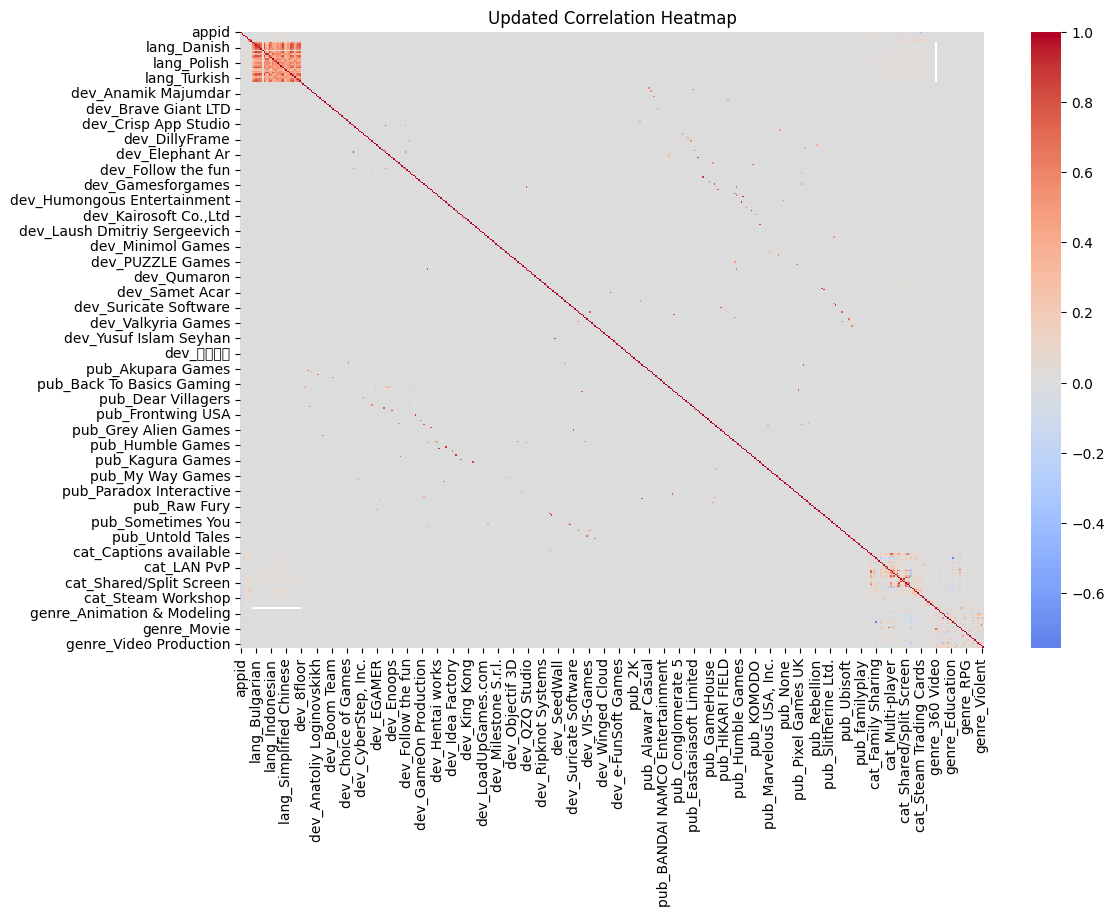

In [57]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_model.corr(), cmap="coolwarm", center=0)
plt.title("Updated Correlation Heatmap")
plt.show()

In [58]:
print(df_model.columns)

Index(['appid', 'required_age', 'price', 'dlc_count', 'windows', 'mac',
       'linux', 'lang_Afrikaans', 'lang_Arabic', 'lang_Bulgarian',
       ...
       'genre_Racing', 'genre_Sexual Content', 'genre_Simulation',
       'genre_Software Training', 'genre_Sports', 'genre_Strategy',
       'genre_Utilities', 'genre_Video Production', 'genre_Violent',
       'genre_Web Publishing'],
      dtype='str', length=443)


## VI. Normalization and Identifying the target
Min-Max normalization was applied to the dataset by first converting the cleaned and reduced dataset into a NumPy array and then scaling it using the MinMaxScaler.

The normalized values were then converted back into a DataFrame with the original column names preserved.

After normalization, the predictor variables and the target variable were separated. The target variable is **USO_Adj Close**, while the remaining columns were used as predictor features.

This ensures that all features are on a comparable scale before applying regression models.

In [59]:
mms = MinMaxScaler()
ex = np.array(df_model)

X_norm = mms.fit_transform(ex)

df_norm = pd.DataFrame(X_norm)
df_norm.columns = df_model.columns

X = df_norm.drop(columns=['average_playtime_forever'])
y = df_norm['average_playtime_forever']

KeyError: "['average_playtime_forever'] not found in axis"

### Now, let's proceed to Linear regression, Ridge and Lasso.

## VII. Linear Regression
Linear Regression is used as the baseline model to understand the relationship between the predictor variables and the target variable.

The model is trained multiple times using different random states to ensure that the evaluation is reliable and not dependent on a single train-test split.

The average training and testing scores are computed to assess how well the model fits the data and generalizes to unseen data.